## tp1

In [85]:
import numpy as np
import pandas as pd

In [86]:
data = pd.read_csv('data/USA_Housing.csv')
data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [88]:
data2=data[['Avg. Area Income','Price']]


In [89]:
x=data2.iloc[:, :-1].values
y=data2.iloc[:, -1].values

In [90]:
x

array([[79545.45857432],
       [79248.64245483],
       [61287.06717866],
       ...,
       [63390.6868855 ],
       [68001.33123509],
       [65510.58180367]], shape=(5000, 1))

In [91]:
y

array([1059033.55787012, 1505890.91484695, 1058987.98787608, ...,
       1030729.58315229, 1198656.87240769, 1298950.48026696],
      shape=(5000,))

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
train_test_split(x, y, test_size=0.25, random_state=40)

[array([[61436.91890629],
        [70950.42998672],
        [76388.55195821],
        ...,
        [80807.73283844],
        [94241.82332287],
        [51796.13357753]], shape=(3750, 1)),
 array([[75391.68175788],
        [85852.14918103],
        [75537.79451   ],
        ...,
        [61875.0759734 ],
        [78318.81449084],
        [75908.67049714]], shape=(1250, 1)),
 array([ 868713.43669433, 1538039.5989439 , 1114729.72452353, ...,
        1304284.2260061 , 2180065.59773864,  891468.21327911],
       shape=(3750,)),
 array([1435769.76883739, 1668448.09805727, 1762214.67958189, ...,
         975005.77366035, 1393995.96182827, 1036277.0624633 ],
       shape=(1250,))]

In [94]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=40)

print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

x_train shape:  (3750, 1)
x_test shape:  (1250, 1)
y_train shape:  (3750,)
y_test shape:  (1250,)


In [95]:
## importation

from sklearn.linear_model import LinearRegression

In [96]:
## creation du modele

modele_lineaire = LinearRegression()

In [97]:
## entraiment  du modele 

modele_lineaire.fit(x_train, y_train)

LinearRegression()

In [98]:
y_price_predits = modele_lineaire.predict(x_test)

y_price_predits

array([1375827.6030198 , 1594792.46082882, 1378886.12389639, ...,
       1092889.80072731, 1437100.12333213, 1386649.52532991],
      shape=(1250,))

In [99]:
y

array([1059033.55787012, 1505890.91484695, 1058987.98787608, ...,
       1030729.58315229, 1198656.87240769, 1298950.48026696],
      shape=(5000,))

In [100]:
resultat=pd.DataFrame(y_test,y_price_predits)
resultat

,0
1.375828e+06,1.435770e+06
1.594792e+06,1.668448e+06
1.378886e+06,1.762215e+06
1.121330e+06,1.106261e+06
1.001248e+06,1.051124e+06
...,...
9.409852e+05,7.054441e+05
1.629427e+06,1.358647e+06
1.092890e+06,9.750058e+05
1.437100e+06,1.393996e+06


In [ ]:
print('MSE de la regression Lineaire:',mean_squared_error(y_test, y_scores_predits))

In [ ]:
print('r2_score de la regression Lineaire:',r2_score(y_test, y_scores_predits))

In [102]:
import matplotlib.pyplot as plt

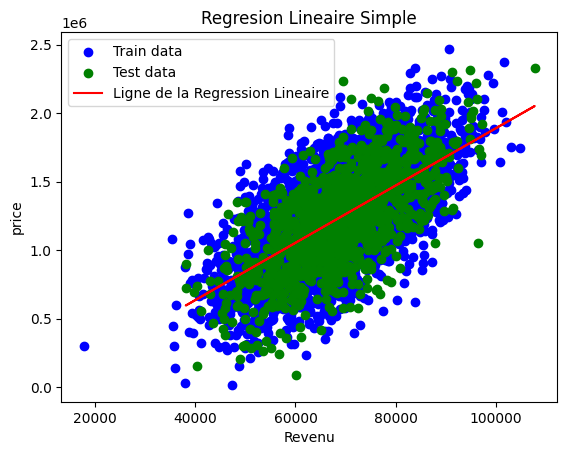

In [103]:
plt.scatter(x_train, y_train, color='blue' , label='Train data')
plt.scatter(x_test, y_test, color='green' , label='Test data')
plt.plot(x_test, y_scores_predits, color='red' , label='Ligne de la Regression Lineaire')
plt.xlabel('Revenu')
plt.ylabel('price')
plt.title('Regresion Lineaire Simple')
plt.legend()
plt.show()

In [104]:
print(modele_lineaire.predict([[63345.240046]]))

[1123664.16807541]


In [106]:
resultats = pd.DataFrame({'y-price-reel':y_test, 'y-scores-predits':y_price_predits,'Difference':y_test-y_price_predits})
resultats

,y-price-reel,y-scores-predits,Difference
0,1.435770e+06,1.375828e+06,59942.165818
1,1.668448e+06,1.594792e+06,73655.637228
2,1.762215e+06,1.378886e+06,383328.555685
3,1.106261e+06,1.121330e+06,-15068.763964
4,1.051124e+06,1.001248e+06,49875.895328
...,...,...,...
1245,7.054441e+05,9.409852e+05,-235541.106927
1246,1.358647e+06,1.629427e+06,-270780.446581
1247,9.750058e+05,1.092890e+06,-117884.027067
1248,1.393996e+06,1.437100e+06,-43104.161504
